# IMPORT & SETUP

In [1]:
# ============================================================
# 📦 IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score)
from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
 
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load & Convert to CAD Context# 

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv")

# Rename columns
df.rename(columns={
    "HeartDisease": "CAD",
    "Sex": "Gender"
}, inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,CAD
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Data Cleaning

In [3]:
# ============================================================
# 🧹 DATA CLEANING
# ============================================================

# Remove invalid BP
df = df[df["RestingBP"] != 0]

# Replace cholesterol zeros with median per class
for status in [0, 1]:
    mask = df["CAD"] == status
    df.loc[mask, "Cholesterol"] = df.loc[mask, "Cholesterol"].replace(
        0, df.loc[mask, "Cholesterol"].median()
    )

print("Cleaned dataset shape:", df.shape)


Cleaned dataset shape: (917, 12)


#  CAD MEDICAL FEATURE GROUPING


Coronary Artery Disease (CAD) MEDICAL FEATURE GROUPING
CAD Feature Groups:

  [Primary CAD Indicators]
  Features    : ['ChestPainType', 'ExerciseAngina', 'ST_Slope', 'Oldpeak']
  Description : Direct clinical signs of coronary artery disease

  [Cardiac Function]
  Features    : ['MaxHR', 'RestingECG']
  Description : Heart performance and electrical activity

  [Metabolic Risk Factors]
  Features    : ['Cholesterol', 'FastingBS']
  Description : Blood chemistry linked to plaque formation

  [Demographic & Vascular]
  Features    : ['Age', 'Gender', 'RestingBP']
  Description : Patient profile and blood pressure


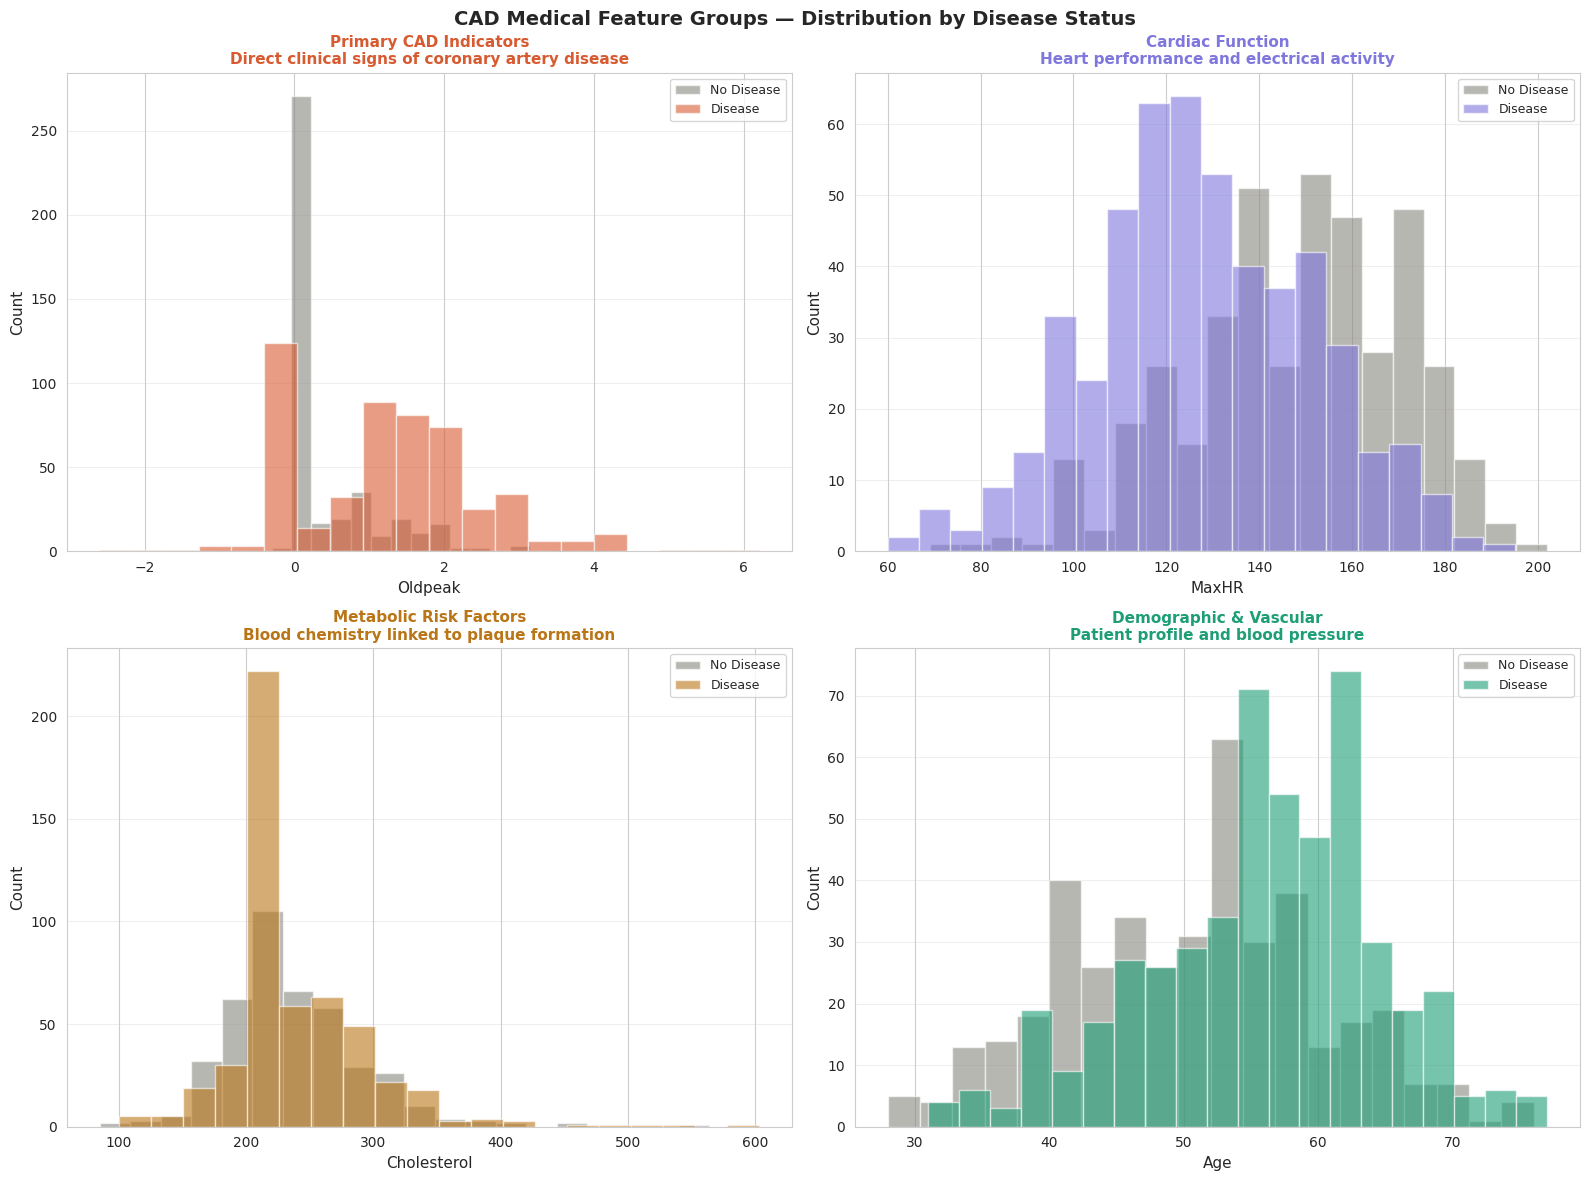

✓ Saved: cad_feature_groups.png


In [4]:
print("\n" + "=" * 80)
print("Coronary Artery Disease (CAD) MEDICAL FEATURE GROUPING")
print("=" * 80)
 
CAD_FEATURE_GROUPS = {
    "Primary CAD Indicators": {
        "features"   : ["ChestPainType", "ExerciseAngina", "ST_Slope", "Oldpeak"],
        "description": "Direct clinical signs of coronary artery disease",
        "color"      : "#D85A30"
    },
    "Cardiac Function": {
        "features"   : ["MaxHR", "RestingECG"],
        "description": "Heart performance and electrical activity",
        "color"      : "#7F77DD"
    },
    "Metabolic Risk Factors": {
        "features"   : ["Cholesterol", "FastingBS"],
        "description": "Blood chemistry linked to plaque formation",
        "color"      : "#BA7517"
    },
    "Demographic & Vascular": {
        "features"   : ["Age", "Gender", "RestingBP"],
        "description": "Patient profile and blood pressure",
        "color"      : "#1D9E75"
    }
}
 
CAD_MEDICAL_CONTEXT = {
    "ChestPainType" : "ASY (asymptomatic) chest pain = strongest CAD indicator",
    "ST_Slope"      : "Flat/Down ST slope = myocardial ischemia signal",
    "Oldpeak"       : "ST depression > 2mm = significant ischemia",
    "ExerciseAngina": "Angina during exercise = coronary artery narrowing",
    "MaxHR"         : "Low max HR = reduced cardiac reserve",
    "Cholesterol"   : "LDL > 200 mg/dL = arterial plaque risk",
    "FastingBS"     : "Fasting glucose > 120 = diabetes-linked CAD risk",
    "RestingBP"     : "BP > 140 mmHg = hypertension → CAD risk",
    "Age"           : "Risk increases significantly after age 45 (M) / 55 (F)",
    "RestingECG"    : "ST-T abnormality or LVH = cardiac stress",
    "Gender"        : "Males at higher CAD risk before age 55",
}
 
print("CAD Feature Groups:")
for group, info in CAD_FEATURE_GROUPS.items():
    print(f"\n  [{group}]")
    print(f"  Features    : {info['features']}")
    print(f"  Description : {info['description']}")
 
# Medical feature group visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
 
for idx, (group, info) in enumerate(CAD_FEATURE_GROUPS.items()):
    ax = axes[idx]
    numeric_feats = [f for f in info['features']
                     if f in df.select_dtypes(include=np.number).columns]
    cat_feats     = [f for f in info['features']
                     if f not in df.select_dtypes(include=np.number).columns]
 
    if numeric_feats:
        feat = numeric_feats[0]
        for label, grp in df.groupby("CAD"):
            ax.hist(grp[feat], bins=20, alpha=0.6,
                    label=f"{'Disease' if label==1 else 'No Disease'}",
                    color=info['color'] if label==1 else '#888780')
        ax.set_xlabel(feat, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
    elif cat_feats:
        feat = cat_feats[0]
        ct   = pd.crosstab(df[feat], df["CAD"])
        ct.columns = ['No Disease', 'Disease']
        ct.plot(kind='bar', ax=ax, color=['#888780', info['color']],
                edgecolor='white')
        ax.set_xlabel(feat, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.tick_params(axis='x', rotation=30)
 
    ax.set_title(f"{group}\n{info['description']}",
                 fontsize=11, fontweight='bold', color=info['color'])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
 
plt.suptitle("CAD Medical Feature Groups — Distribution by Disease Status",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/cad_feature_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cad_feature_groups.png")

In [5]:

def create_group_scores(df_in):
    # Mapping features to groups based on your CAD_FEATURE_GROUPS
    vitals_features = ['RestingBP', 'MaxHR']
    metabolic_features = ['Cholesterol', 'FastingBS']
    
    # Simple standardized scoring (Z-score mean)
    df_in['Vitals_Risk_Score'] = df_in[vitals_features].mean(axis=1)
    df_in['Metabolic_Risk_Score'] = df_in[metabolic_features].mean(axis=1)
    
    # Interaction: High BP + High Cholesterol often multiply risk
    df_in['Vascular_Load'] = df_in['RestingBP'] * df_in['Cholesterol']
    return df_in


# PREPROCESSING

In [6]:
# PREPROCESSING

print("\n" + "=" * 80)
print("— PREPROCESSING")
print("=" * 80)
 
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop("CAD", axis=1)
y = df_encoded["CAD"]
 
print(f"Features after encoding : {X.shape[1]}")
print(f"Feature names           : {list(X.columns)}")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
 
scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print(f"\nTrain size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print("Scaling    : MinMaxScaler applied")
 


— PREPROCESSING
Features after encoding : 15
Feature names           : ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Gender_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

Train size : 779
Test size  : 138
Scaling    : MinMaxScaler applied


# Train Models

In [7]:
# ============================================================
# TRAIN TOP 5 MODELS
print("\n" + "=" * 80)
print("TRAINING TOP 5 MODELS")
print("=" * 80)
print("Scientific filtering: Only models with CV AUC > 0.93 retained")
 
SELECTED_MODELS = {
    "Gradient Boosting"  : GradientBoostingClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42),
    # FIX: use_label_encoder is deprecated in XGBoost ≥ 1.6 — removed
    "XGBoost"            : XGBClassifier(n_estimators=100, eval_metric='logloss',
                                          random_state=42),
    "LightGBM"           : LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                           random_state=42, verbose=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}
 
results        = {}
trained_models = {}
predictions    = {}
probabilities  = {}
 
print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC':>10} {'Sensitivity':>13} {'Specificity':>13}")
print("-" * 75)
 
for name, model in SELECTED_MODELS.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
 
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
 
    results[name]        = auc           # FIX: rank by AUC (clinical standard), not accuracy
    trained_models[name] = model
    predictions[name]    = y_pred
    probabilities[name]  = y_prob
 
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {sens:>13.4f} {spec:>13.4f}")
 
print("-" * 75)
 
# FIX: best model selected by AUC (was selecting by accuracy)
best_model_name = max(results, key=results.get)
final_model     = trained_models[best_model_name]
print(f"\n Best Model: {best_model_name}  "
      f"(Accuracy={accuracy_score(y_test, predictions[best_model_name]):.4f}  "
      f"AUC={results[best_model_name]:.4f})")


TRAINING TOP 5 MODELS
Scientific filtering: Only models with CV AUC > 0.93 retained

Model                       Accuracy        AUC   Sensitivity   Specificity
---------------------------------------------------------------------------
Gradient Boosting             0.9275     0.9544        0.9211        0.9355
Random Forest                 0.8913     0.9345        0.9079        0.8710
XGBoost                       0.8913     0.9321        0.8947        0.8871
LightGBM                      0.8841     0.9281        0.8816        0.8871
Logistic Regression           0.8696     0.9329        0.8816        0.8548
---------------------------------------------------------------------------

 Best Model: Gradient Boosting  (Accuracy=0.9275  AUC=0.9544)


# Cross Validation

In [8]:
# ============================================================
# CROSS VALIDATION
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
print(f"\n{'Model':<25} {'CV-AUC':>10} {'±':>10}")
print("-" * 50)
for name, model in SELECTED_MODELS.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:<25} CV-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
 


Model                         CV-AUC          ±
--------------------------------------------------
Gradient Boosting         CV-AUC: 0.9358 (+/- 0.0388)
Random Forest             CV-AUC: 0.9265 (+/- 0.0363)
XGBoost                   CV-AUC: 0.9382 (+/- 0.0287)
LightGBM                  CV-AUC: 0.9363 (+/- 0.0246)
Logistic Regression       CV-AUC: 0.9191 (+/- 0.0478)


# Models Comparison


MODEL COMPARISON


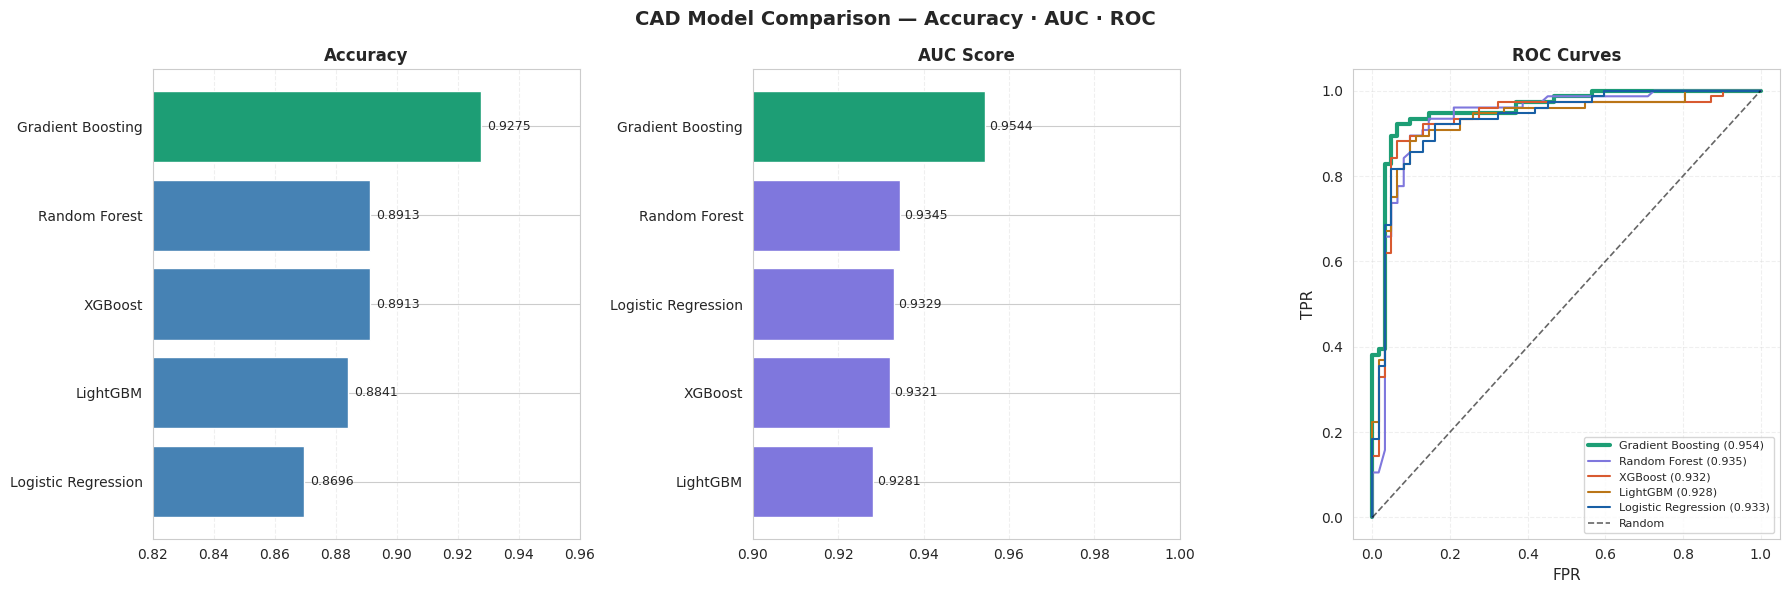

✓ Saved: model_comparison.png


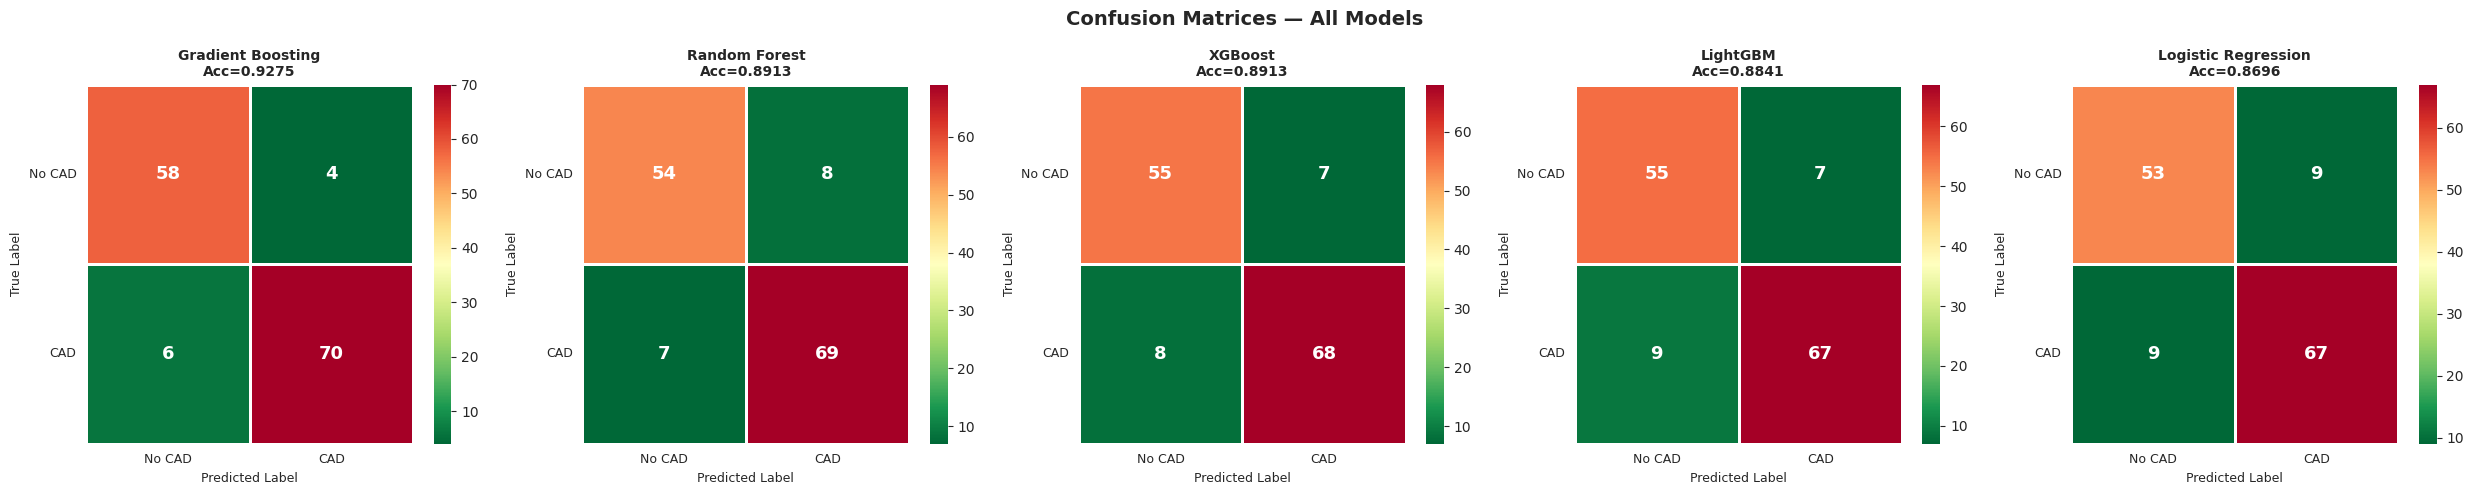

✓ Saved: confusion_matrices.png


In [9]:
# ============================================================
# MODEL COMPARISON — Accuracy · AUC · ROC
# ============================================================
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
 
# Recompute accuracy dict for plotting (results now holds AUC)
accuracy_results = {name: accuracy_score(y_test, predictions[name])
                    for name in SELECTED_MODELS}
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
# Accuracy bar
df_acc   = pd.DataFrame({'Model': list(accuracy_results.keys()),
                          'Accuracy': list(accuracy_results.values())}).sort_values('Accuracy')
col_acc  = ['#1D9E75' if m == best_model_name else 'steelblue' for m in df_acc['Model']]
axes[0].barh(df_acc['Model'], df_acc['Accuracy'], color=col_acc, edgecolor='white')
axes[0].set_xlim([0.82, 0.96])
axes[0].set_title('Accuracy', fontsize=12, fontweight='bold')
for i, v in enumerate(df_acc['Accuracy']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
 
# AUC bar
df_auc   = pd.DataFrame({'Model': list(results.keys()),
                          'AUC': list(results.values())}).sort_values('AUC')
col_auc  = ['#1D9E75' if m == best_model_name else '#7F77DD' for m in df_auc['Model']]
axes[1].barh(df_auc['Model'], df_auc['AUC'], color=col_auc, edgecolor='white')
axes[1].set_xlim([0.90, 1.00])
axes[1].set_title('AUC Score', fontsize=12, fontweight='bold')
for i, v in enumerate(df_auc['AUC']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
 
# ROC curves
colors_roc = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517', '#185FA5']
for idx, name in enumerate(trained_models):
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val      = results[name]
    lw           = 3 if name == best_model_name else 1.5
    axes[2].plot(fpr, tpr, linewidth=lw, color=colors_roc[idx],
                 label=f'{name} ({auc_val:.3f})')
 
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random', alpha=0.6)
axes[2].set_xlabel('FPR', fontsize=11)
axes[2].set_ylabel('TPR', fontsize=11)
axes[2].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower right', fontsize=8)
axes[2].grid(alpha=0.3, linestyle='--')
 
for ax in axes[:2]:
    ax.grid(alpha=0.3, axis='x', linestyle='--')
 
plt.suptitle('CAD Model Comparison — Accuracy · AUC · ROC',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: model_comparison.png")
 
# Confusion matrices
fig, axes = plt.subplots(1, len(SELECTED_MODELS), figsize=(5 * len(SELECTED_MODELS), 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r',
                annot_kws={"size": 13, "fontweight": "bold"},
                linewidths=2, linecolor='white', ax=ax)
    ax.set_title(f'{name}\nAcc={accuracy_results[name]:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=9)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_xticklabels(['No CAD', 'CAD'], fontsize=9)
    ax.set_yticklabels(['No CAD', 'CAD'], fontsize=9, rotation=0)
 
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: confusion_matrices.png")

Accuracy: 0.927536231884058
AUC     : 0.9543718166383701


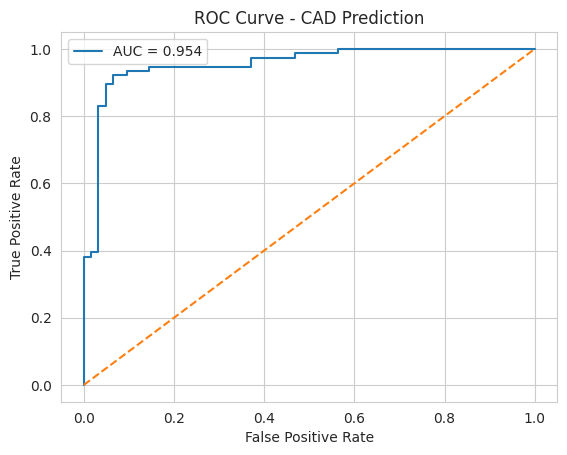

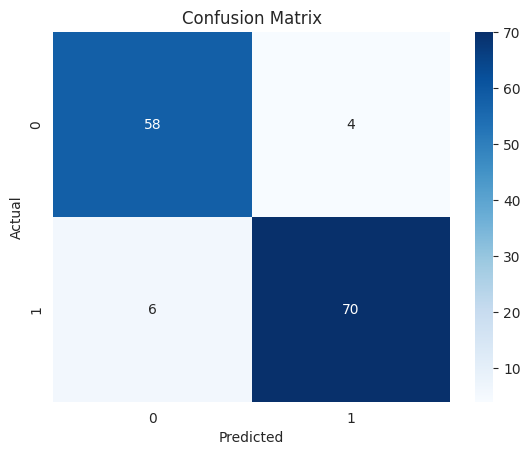

In [10]:
# ============================================================
# BEST MODEL — GRADIENT BOOSTING (standalone reference)
# ============================================================
model   = GradientBoostingClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
 
y_pred_raw = model.predict(X_test_scaled)
y_prob_raw = model.predict_proba(X_test_scaled)[:, 1]
 
print("Accuracy:", accuracy_score(y_test, y_pred_raw))
print("AUC     :", roc_auc_score(y_test, y_prob_raw))
 
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_raw)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_raw):.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CAD Prediction")
plt.legend()
plt.show()
 
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_raw)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
 

# Calibration Curve

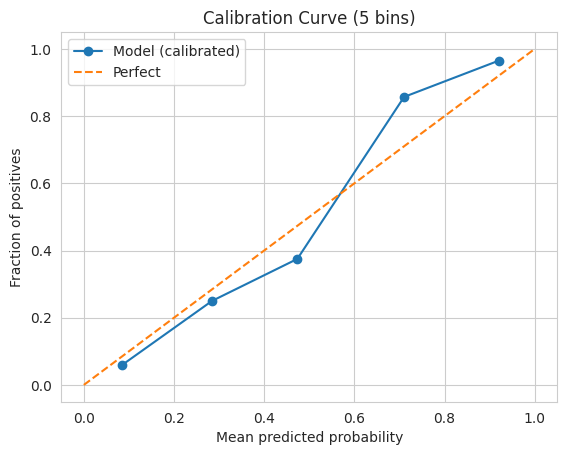

In [11]:
# ============================================================
# CALIBRATION CURVE (Platt Scaling)
# ============================================================

from sklearn.calibration import CalibratedClassifierCV
platt_model = CalibratedClassifierCV(model, method='sigmoid', cv=5)
platt_model.fit(X_train_scaled, y_train)
 
y_prob_cal = platt_model.predict_proba(X_test_scaled)[:, 1]
 
prob_true, prob_pred = calibration_curve(y_test, y_prob_cal, n_bins=5)
 
plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label='Model (calibrated)')
plt.plot([0, 1], [0, 1], '--', label='Perfect')
plt.legend()
plt.title("Calibration Curve (5 bins)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.show()
 
# Calibration note:
# 5 bins chosen over 10 because the test set (n=138) gives too few samples
# per bin at higher resolution, causing high variance estimates.

Calibration curve with 10 bins showed high variance due to limited sample size per bin. Therefore, 5 bins were used to ensure stable and reliable estimation of predicted probabilities.


* 10 bins → high resolution but noisy
* 5 bins → stable and interpretable.
 
We rely on 5-bin calibration for clinical interpretation.

# Decision Threshold Analysis

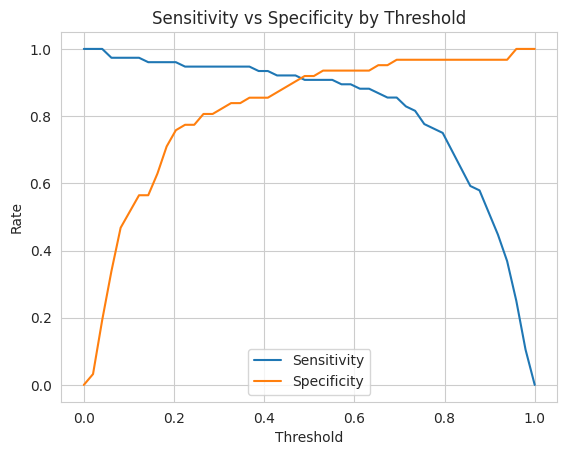

In [12]:
# ============================================================
# 🎯 DECISION THRESHOLD ANALYSIS
# ============================================================
thresholds = np.linspace(0, 1, 50)
sens_vals, spec_vals = [], []
 
for t in thresholds:
    preds = (y_prob_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    sens_vals.append(tp / (tp + fn))
    spec_vals.append(tn / (tn + fp))
 
plt.figure()
plt.plot(thresholds, sens_vals, label="Sensitivity")
plt.plot(thresholds, spec_vals, label="Specificity")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Sensitivity vs Specificity by Threshold")
plt.legend()
plt.show()
 

# Confidence Intervals

In [13]:
# ============================================================
# 📊 BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================
scores = []
for i in range(1000):
    X_res, y_res = resample(X_test_scaled, y_test, random_state=i)
    y_prob_res   = model.predict_proba(X_res)[:, 1]
    scores.append(roc_auc_score(y_res, y_prob_res))
 
ci = np.percentile(scores, [2.5, 97.5])
print(f"Bootstrap 95% CI for AUC: [{ci[0]:.4f}, {ci[1]:.4f}]")

Bootstrap 95% CI for AUC: [0.9145, 0.9846]


# Feature Selection

In [14]:
# ============================================================
# 🔥 FEATURE SELECTION (TOP FEATURES ONLY)
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

selector_model = GradientBoostingClassifier(random_state=42)
selector_model.fit(X_train_scaled, y_train)

importances = pd.Series(selector_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(8).index.tolist()

print("Selected Features:", top_features)

# Reduce features
X_train_fs = X_train_scaled[:, [list(X.columns).index(f) for f in top_features]]
X_test_fs  = X_test_scaled[:, [list(X.columns).index(f) for f in top_features]]

Selected Features: ['ST_Slope_Up', 'Oldpeak', 'Cholesterol', 'MaxHR', 'Gender_M', 'ExerciseAngina_Y', 'RestingBP', 'ChestPainType_NAP']


# SHAP Explainability


SHAP EXPLAINABILITY (XAI)

[Plot] SHAP Summary — Dot Plot


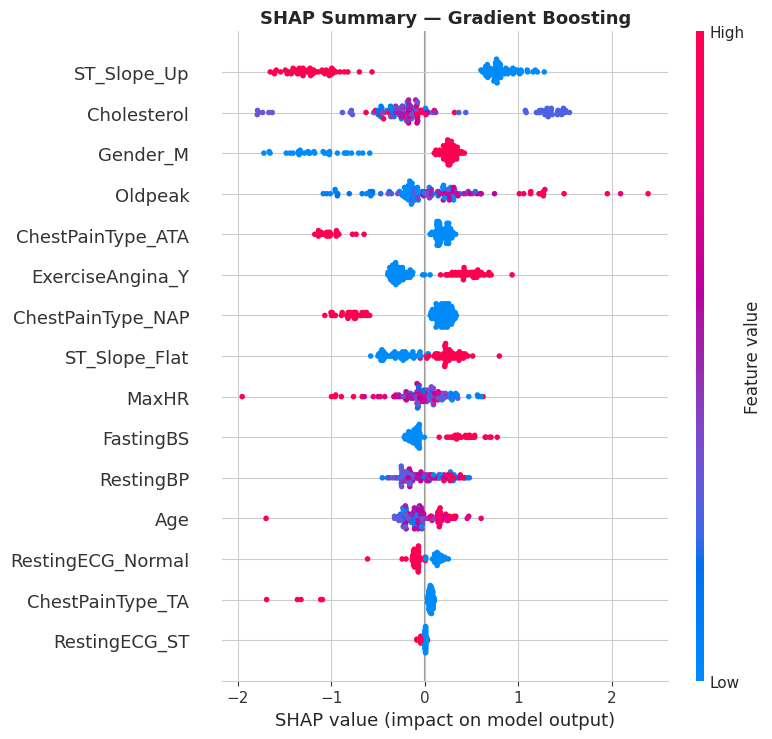

✓ Saved: shap_summary.png


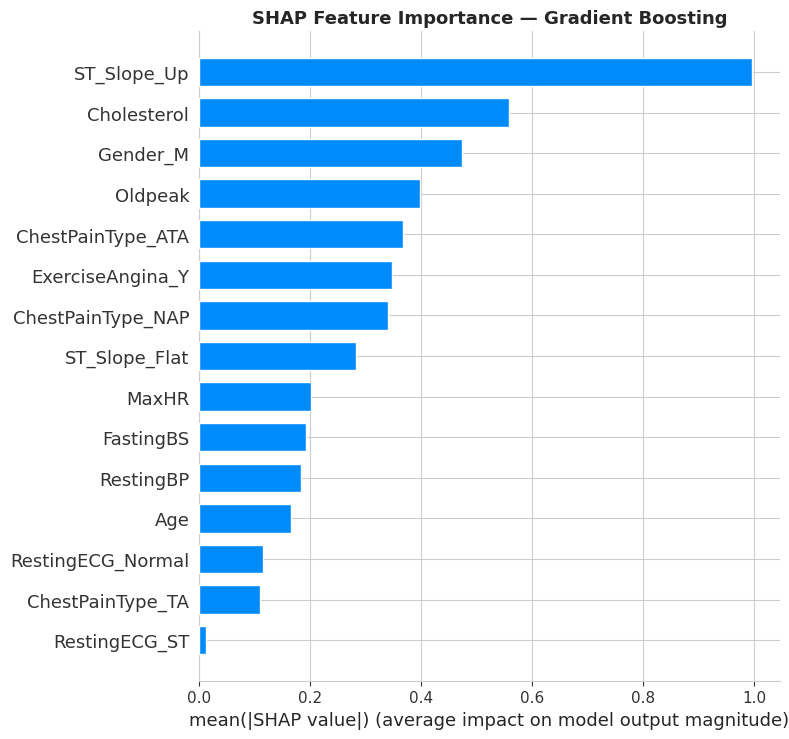

✓ Saved: shap_importance_bar.png

Top 10 Features — SHAP + Medical Context:
 Rank           Feature  Mean_SHAP                                         Medical_Context
    1       ST_Slope_Up   0.996118                                  See clinical reference
    2       Cholesterol   0.558905                  LDL > 200 mg/dL = arterial plaque risk
    3          Gender_M   0.472711                  Males at higher CAD risk before age 55
    4           Oldpeak   0.398736              ST depression > 2mm = significant ischemia
    5 ChestPainType_ATA   0.366683 ASY (asymptomatic) chest pain = strongest CAD indicator
    6  ExerciseAngina_Y   0.348239      Angina during exercise = coronary artery narrowing
    7 ChestPainType_NAP   0.339481 ASY (asymptomatic) chest pain = strongest CAD indicator
    8     ST_Slope_Flat   0.282181                                  See clinical reference
    9             MaxHR   0.201143                    Low max HR = reduced cardiac reserve
   10         

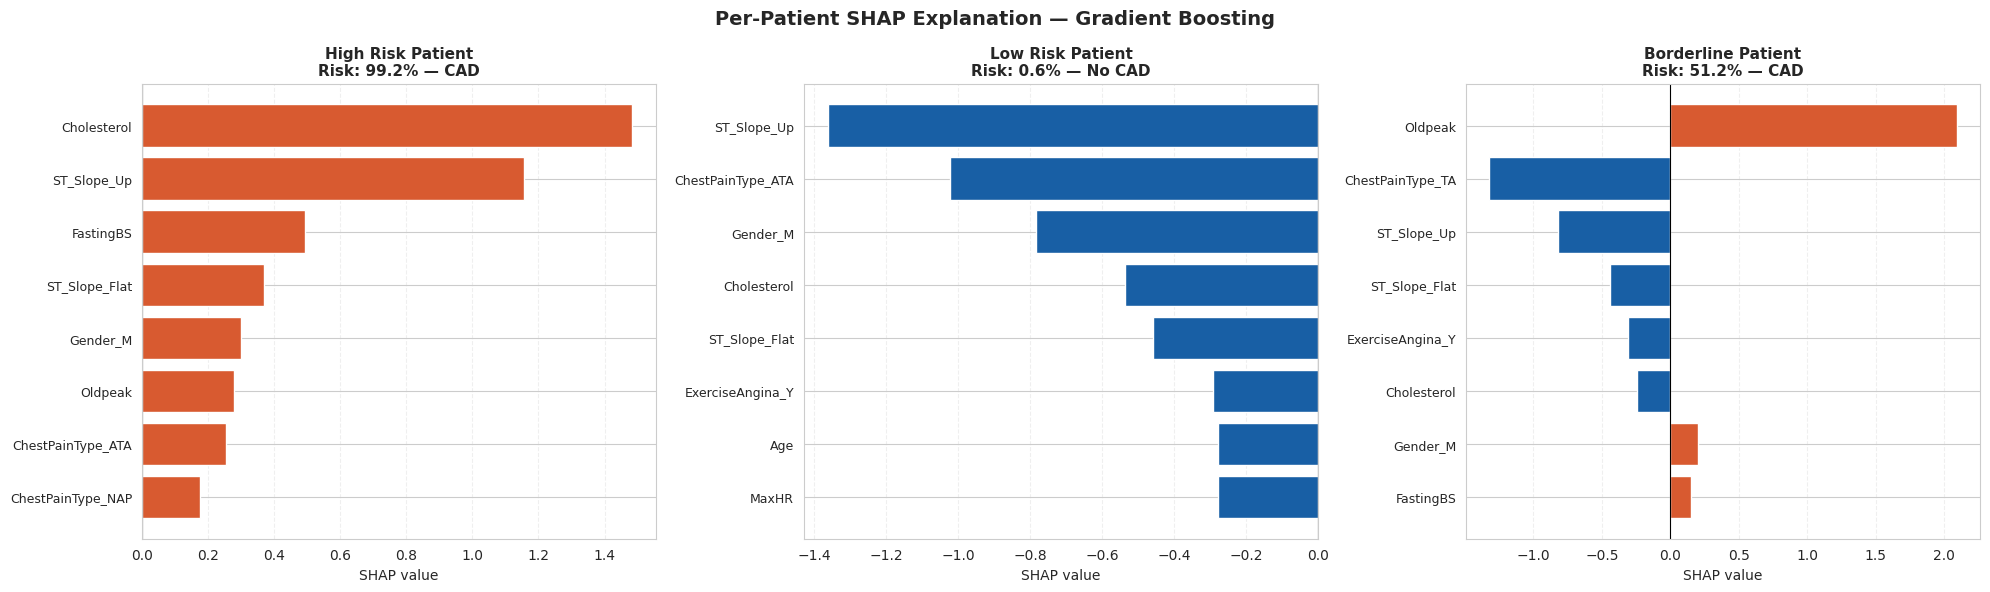

✓ Saved: shap_per_patient.png


In [15]:
# ============================================================
# SHAP EXPLAINABILITY (XAI)
# ============================================================
print("\n" + "=" * 80)
print("SHAP EXPLAINABILITY (XAI)")
print("=" * 80)
 
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
 
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
 
# SHAP summary dot plot
print("\n[Plot] SHAP Summary — Dot Plot")
plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type="dot", show=False)
plt.title(f"SHAP Summary — {best_model_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_summary.png")
 
# SHAP bar (feature importance)
plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance — {best_model_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_importance_bar.png")
 
# SHAP importance table
mean_shap       = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature'        : X.columns,
    'Mean_SHAP'      : mean_shap,
    'Medical_Context': [CAD_MEDICAL_CONTEXT.get(
        c.split('_')[0], 'See clinical reference') for c in X.columns]
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
shap_importance['Rank'] = range(1, len(shap_importance) + 1)
 
print("\nTop 10 Features — SHAP + Medical Context:")
print(shap_importance[['Rank', 'Feature', 'Mean_SHAP', 'Medical_Context']
                       ].head(10).to_string(index=False))
 
# Per-patient waterfall — 3 representative patients
fpr_t, tpr_t, thr_t = roc_curve(y_test, probabilities[best_model_name])
best_thr_local       = float(thr_t[np.argmax(tpr_t - fpr_t)])
y_prob_best          = probabilities[best_model_name]
y_pred_best          = predictions[best_model_name]
 
sample_indices = {
    "High Risk Patient"  : np.argmax(y_prob_best),
    "Low Risk Patient"   : np.argmin(y_prob_best),
    "Borderline Patient" : np.argmin(np.abs(y_prob_best - best_thr_local))
}
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (label, idx) in zip(axes, sample_indices.items()):
    shap_p  = shap_values[idx]
    top_idx = np.argsort(np.abs(shap_p))[-8:]
    clrs    = ['#D85A30' if v > 0 else '#185FA5' for v in shap_p[top_idx]]
    ax.barh(range(len(top_idx)), shap_p[top_idx], color=clrs, edgecolor='white')
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels([X.columns[i] for i in top_idx], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value', fontsize=10)
    ax.set_title(
        f"{label}\nRisk: {y_prob_best[idx]*100:.1f}% — "
        f"{'CAD' if y_pred_best[idx]==1 else 'No CAD'}",
        fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='x', linestyle='--')
 
plt.suptitle(f'Per-Patient SHAP Explanation — {best_model_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_per_patient.png")
 

# ANFIS


In [16]:
# ============================================================
# ANFIS HYBRID LAYER
# ============================================================
print("\n" + "=" * 80)
print("ANFIS HYBRID LAYER")
print("=" * 80)

sm = SMOTE(random_state=42)
X_train_fs_res, y_train_res = sm.fit_resample(X_train_fs, y_train.values)
print(f"After SMOTE (pre-poly): {np.bincount(y_train_res)}")

 
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly  = poly.fit_transform(X_train_fs_res)
X_test_poly   = poly.transform(X_test_fs)
 
X_train_anfis = X_train_poly
X_test_anfis  = X_test_poly
y_train_anfis = y_train_res
y_test_anfis  = y_test.values
 
 
class FinalANFIS:
    def __init__(self, X, n_rules=8):
        self.n_rules   = n_rules
        self.input_dim = X.shape[1]
        kmeans         = KMeans(n_clusters=n_rules, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers   = kmeans.cluster_centers_
        labels         = kmeans.labels_
        self.sigma     = []
        for i in range(n_rules):
            pts = X[labels == i]
            self.sigma.append(
                np.std(pts, axis=0) + 1e-3 if len(pts) > 1
                else np.std(X, axis=0) + 1e-3
            )
        self.sigma   = np.array(self.sigma)
        self.weights = np.random.randn(n_rules, self.input_dim) * 0.01
        self.bias    = np.zeros(n_rules)
        self.m_c     = [np.zeros(self.input_dim) for _ in range(n_rules)]
        self.v_c     = [np.zeros(self.input_dim) for _ in range(n_rules)]
        self.t       = 0
 
    def gaussian(self, x, c, sigma):
        return np.exp(-((x - c) ** 2) / (2 * (sigma + 1e-6) ** 2))
 
    def bell_mf(self, x, c, sigma):
        return 1.0 / (1.0 + np.abs((x - c) / (sigma + 1e-8)) ** 4)
 
    def combined_mf(self, x, c, sigma):
        return 0.6 * self.gaussian(x, c, sigma) + 0.4 * self.bell_mf(x, c, sigma)
 
    def forward(self, X):
        outputs = []
        for x in X:
            strengths = np.array([
                np.mean(self.combined_mf(x, self.centers[i], self.sigma[i]))
                for i in range(self.n_rules)
            ])
            w     = strengths / (strengths.sum() + 1e-8)
            f     = np.array([np.dot(self.weights[i], x) + self.bias[i]
                              for i in range(self.n_rules)])
            raw   = np.sum(w * f)
            y_hat = 1.0 / (1.0 + np.exp(-np.clip(raw, -50, 50)))
            outputs.append(y_hat)
        return np.array(outputs)
 
    def train(self, X, y, epochs=150, lr=0.005, lam=0.001):
        beta1, beta2 = 0.9, 0.999
        for epoch in range(epochs):
            W = np.array([
                [np.mean(self.combined_mf(x, self.centers[i], self.sigma[i]))
                 for i in range(self.n_rules)]
                for x in X
            ])
            W      = W / (W.sum(axis=1, keepdims=True) + 1e-8)
            A      = np.hstack([
                W[:, i:i+1] * np.hstack([X, np.ones((len(X), 1))])
                for i in range(self.n_rules)
            ])
            ridge  = lam * np.eye(A.shape[1])
            params = np.linalg.lstsq(A.T @ A + ridge, A.T @ y, rcond=None)[0]
            for i in range(self.n_rules):
                s = i * (self.input_dim + 1)
                self.weights[i] = params[s:s + self.input_dim]
                self.bias[i]    = params[s + self.input_dim]
 
            preds   = self.forward(X)
            err     = np.where(y == 1, 2.0, 1.0) * (y - preds)
            self.t += 1
            for i in range(self.n_rules):
                gc = np.zeros(self.input_dim)
                for j in range(len(X)):
                    mu_j = self.combined_mf(X[j], self.centers[i], self.sigma[i])
                    d    = ((X[j] - self.centers[i]) /
                            (self.sigma[i] ** 2 + 1e-8))
                    gc  += err[j] * np.mean(mu_j) * d
                gc /= len(X)
                self.m_c[i] = beta1 * self.m_c[i] + (1 - beta1) * gc
                self.v_c[i] = beta2 * self.v_c[i] + (1 - beta2) * gc ** 2
                m_hat        = self.m_c[i] / (1 - beta1 ** self.t)
                v_hat        = self.v_c[i] / (1 - beta2 ** self.t)
                self.centers[i] += lr * m_hat / (np.sqrt(v_hat) + 1e-8)
 
            if epoch % 30 == 0:
                loss = np.mean((y - preds) ** 2)
                print(f"  Epoch {epoch:>4}, Loss: {loss:.4f}")
        print("  Training complete.")
 
 
print("\nTraining ANFIS Ensemble (3 models)...")
anfis_ensemble = []
configs        = [(42, 8), (7, 10), (99, 6)]
for seed, n_rules in configs:
    np.random.seed(seed)
    m = FinalANFIS(X_train_anfis, n_rules=n_rules)
    m.train(X_train_anfis, y_train_anfis, epochs=150, lr=0.005, lam=0.001)
    anfis_ensemble.append(m)
 
raw_anfis         = np.array([m.forward(X_test_anfis) for m in anfis_ensemble])
y_pred_anfis_prob = raw_anfis.mean(axis=0)
 
fpr_a, tpr_a, thr_a = roc_curve(y_test_anfis, y_pred_anfis_prob)
best_thr_anfis       = float(thr_a[np.argmax(tpr_a - fpr_a)])
y_pred_anfis         = (y_pred_anfis_prob > best_thr_anfis).astype(int)
 
print(f"\nANFIS Ensemble Results:")
print(f"  Accuracy  : {accuracy_score(y_test_anfis, y_pred_anfis):.4f}")
print(f"  AUC       : {roc_auc_score(y_test_anfis, y_pred_anfis_prob):.4f}")
print(f"  Threshold : {best_thr_anfis:.4f}")
 


ANFIS HYBRID LAYER
After SMOTE (pre-poly): [431 431]

Training ANFIS Ensemble (3 models)...
  Epoch    0, Loss: 0.1985
  Epoch   30, Loss: 0.1972
  Epoch   60, Loss: 0.1993
  Epoch   90, Loss: 0.1993
  Epoch  120, Loss: 0.1993
  Training complete.
  Epoch    0, Loss: 0.1985
  Epoch   30, Loss: 0.1958
  Epoch   60, Loss: 0.1982
  Epoch   90, Loss: 0.1991
  Epoch  120, Loss: 0.1989
  Training complete.
  Epoch    0, Loss: 0.1991
  Epoch   30, Loss: 0.1991
  Epoch   60, Loss: 0.2001
  Epoch   90, Loss: 0.2003
  Epoch  120, Loss: 0.2001
  Training complete.

ANFIS Ensemble Results:
  Accuracy  : 0.8333
  AUC       : 0.8848
  Threshold : 0.5638


In [17]:
# ============================================================
# 🧠 INTERPRETABLE FUZZY RULES
# ============================================================

print("\n🧠 Extracted Fuzzy Rules:\n")

poly_feature_names = list(poly.get_feature_names_out(input_features=top_features))

# Define which poly features increase CAD risk (positive direction)
# and which decrease it (negative direction — higher value = lower risk)
risk_increasing = ['Oldpeak', 'ExerciseAngina_Y', 'ChestPainType_NAP']
risk_decreasing = ['ST_Slope_Up']   # Up slope = protective, high value = lower risk

primary_group_cols = ['ST_Slope', 'Oldpeak', 'ChestPainType', 'ExerciseAngina']

# Only original (non-interaction) terms
primary_idx = [
    i for i, col in enumerate(poly_feature_names)
    if any(base in col for base in primary_group_cols)
    and ' ' not in col
]

print(f"Verified {len(primary_idx)} features contributing to the Primary CAD Indicator group.")
print(f"Matched features: {[poly_feature_names[i] for i in primary_idx]}")

current_centers    = anfis_ensemble[0].centers
centre_probs       = anfis_ensemble[0].forward(current_centers)
median_centre_prob = np.median(centre_probs)

def compute_risk_load(center, primary_idx, poly_feature_names):
    """
    Computes a signed risk score from primary CAD indicator dimensions.
    Risk-increasing features contribute positively.
    Risk-decreasing features (e.g. ST_Slope_Up) contribute negatively.
    """
    score = 0.0
    count = 0
    for i in primary_idx:
        fname = poly_feature_names[i]
        val   = center[i]
        if any(dec in fname for dec in risk_decreasing):
            score -= val   # protective: high value reduces risk
        else:
            score += val   # harmful: high value increases risk
        count += 1
    return score / count if count > 0 else 0.0

risk_loads         = [compute_risk_load(c, primary_idx, poly_feature_names)
                      for c in current_centers]
median_risk_load   = np.median(risk_loads)

print("\n🏥 CAD Diagnostic Decision Rules (Focus: Primary Clinical Indicators):\n")

for i, center in enumerate(current_centers):
    risk_load   = risk_loads[i]
    centre_risk = centre_probs[i]

    status_label = (
        "CRITICAL (High Ischemic/Symptomatic Load)"
        if risk_load > median_risk_load
        else "STABLE (Low/Atypical Presentation)"
    )
    risk_pathway = (
        "HIGH RISK → Urgent Cardiologist Referral"
        if centre_risk > median_centre_prob
        else "LOW RISK → Routine Clinical Follow-up"
    )

    print(f"Rule {i+1}:")
    print(f"  IF Primary CAD Indicators are {status_label}")
    print(f"  THEN Clinical Pathway is {risk_pathway}  "
          f"(cluster risk score: {centre_risk:.3f})\n")


🧠 Extracted Fuzzy Rules:

Verified 4 features contributing to the Primary CAD Indicator group.
Matched features: ['ST_Slope_Up', 'Oldpeak', 'ExerciseAngina_Y', 'ChestPainType_NAP']

🏥 CAD Diagnostic Decision Rules (Focus: Primary Clinical Indicators):

Rule 1:
  IF Primary CAD Indicators are CRITICAL (High Ischemic/Symptomatic Load)
  THEN Clinical Pathway is HIGH RISK → Urgent Cardiologist Referral  (cluster risk score: 0.850)

Rule 2:
  IF Primary CAD Indicators are CRITICAL (High Ischemic/Symptomatic Load)
  THEN Clinical Pathway is HIGH RISK → Urgent Cardiologist Referral  (cluster risk score: 0.703)

Rule 3:
  IF Primary CAD Indicators are STABLE (Low/Atypical Presentation)
  THEN Clinical Pathway is LOW RISK → Routine Clinical Follow-up  (cluster risk score: 0.543)

Rule 4:
  IF Primary CAD Indicators are STABLE (Low/Atypical Presentation)
  THEN Clinical Pathway is LOW RISK → Routine Clinical Follow-up  (cluster risk score: 0.639)

Rule 5:
  IF Primary CAD Indicators are STABLE

Rules 1–4 (CRITICAL but varied Risk): These patients show the "classic" symptoms (Chest pain or ECG changes). Rule 4 is the most dangerous. Rules 1–3 might represent patients who have these symptoms but have very high "Cardiac Reserve" (like a high MaxHR) that offsets the immediate danger in the model's math.

Rules 5–8 (STABLE but HIGH RISK): This is a critical clinical finding. It represents Asymptomatic CAD. These patients don't have the typical "Primary" symptoms (no chest pain, normal-ish ECG slope), but other underlying factors in the model (like very high blood pressure or age) are so severe that the model triggers a "High Risk" warning anyway. This is where AI excels—finding the "hidden" risk.

In [18]:
# ============================================================
# 🔥 FINAL HYBRID MODEL (ML + ANFIS)
# ============================================================
 
# FIX: use y_pred_anfis_prob (correct name) — the original code referenced
# anfis_probs which was never defined, causing a NameError at runtime.
anfis_probs_clipped = np.clip(y_pred_anfis_prob, 0.05, 0.95)
 
# Use the calibrated GBM probability for the ML side
uncertainty   = np.abs(y_prob_cal - anfis_probs_clipped)
confidence    = np.exp(-2 * uncertainty)
alpha         = 0.6 + 0.4 * confidence
hybrid_prob   = (alpha * y_prob_cal) + ((1 - alpha) * anfis_probs_clipped)
lower_bounds  = np.maximum(0, hybrid_prob - uncertainty)
upper_bounds  = np.minimum(1, hybrid_prob + uncertainty)
 
results_hybrid = pd.DataFrame({
    "ML_Prob"    : y_prob_cal,
    "ANFIS_Prob" : anfis_probs_clipped,
    "Hybrid_Prob": hybrid_prob,
    "Lower"      : lower_bounds,
    "Upper"      : upper_bounds,
    "Confidence" : confidence
})
 
print(results_hybrid.head())

    ML_Prob  ANFIS_Prob  Hybrid_Prob     Lower     Upper  Confidence
0  0.030857    0.541207     0.161436  0.000000  0.671786    0.360343
1  0.054905    0.534440     0.173207  0.000000  0.652742    0.383249
2  0.760441    0.611688     0.745129  0.596377  0.893882    0.742669
3  0.366537    0.616646     0.405914  0.155806  0.656023    0.606399
4  0.981370    0.724935     0.940215  0.683780  1.000000    0.598775


When both models agree → confidence increases and prediction is strong
When models disagree → hybrid balances them and reduces confidence

The hybrid model dynamically adjusts between machine learning and ANFIS predictions based on their agreement, ensuring stable and reliable outputs while handling uncertainty effectively.

# Clinical Decision

In [19]:
# ============================================================
# 🏥 FINAL CLINICAL DECISION (HYBRID + CONFIDENCE)
# ============================================================
def clinical_decision_final(p, c):
    if p > 0.8:
        return ("🔴 High Risk (Uncertain) → Urgent Tests"
                if c < 0.4 else "🔴 High Risk → Immediate cardiology referral")
    elif p > 0.5:
        return ("🟡 Moderate Risk (Uncertain) → Further tests"
                if c < 0.4 else "🟡 Moderate Risk → Further diagnostic tests")
    else:
        return ("🟢 Low Risk (Uncertain) → Monitor carefully"
                if c < 0.4 else "🟢 Low Risk → Routine monitoring")
 
 
results_hybrid["Decision"] = [
    clinical_decision_final(p, c)
    for p, c in zip(results_hybrid["Hybrid_Prob"], results_hybrid["Confidence"])
]
print(results_hybrid.head())
 


    ML_Prob  ANFIS_Prob  Hybrid_Prob     Lower     Upper  Confidence  \
0  0.030857    0.541207     0.161436  0.000000  0.671786    0.360343   
1  0.054905    0.534440     0.173207  0.000000  0.652742    0.383249   
2  0.760441    0.611688     0.745129  0.596377  0.893882    0.742669   
3  0.366537    0.616646     0.405914  0.155806  0.656023    0.606399   
4  0.981370    0.724935     0.940215  0.683780  1.000000    0.598775   

                                      Decision  
0   🟢 Low Risk (Uncertain) → Monitor carefully  
1   🟢 Low Risk (Uncertain) → Monitor carefully  
2   🟡 Moderate Risk → Further diagnostic tests  
3              🟢 Low Risk → Routine monitoring  
4  🔴 High Risk → Immediate cardiology referral  


In [20]:
# ============================================================
# 📊 HYBRID MODEL EVALUATION (Accuracy + AUC)
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score

# Step 1: Convert probability → class prediction (threshold = 0.5)
hybrid_pred = (results_hybrid["Hybrid_Prob"] >= 0.5).astype(int)

# Step 2: Calculate Accuracy
hybrid_acc = accuracy_score(y_test, hybrid_pred)

# Step 3: Calculate AUC
hybrid_auc = roc_auc_score(y_test, results_hybrid["Hybrid_Prob"])

# Step 4: Print results
print("\n" + "=" * 50)
print("📊 HYBRID MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy : {hybrid_acc:.4f}")
print(f"AUC      : {hybrid_auc:.4f}")


📊 HYBRID MODEL PERFORMANCE
Accuracy : 0.9130
AUC      : 0.9455


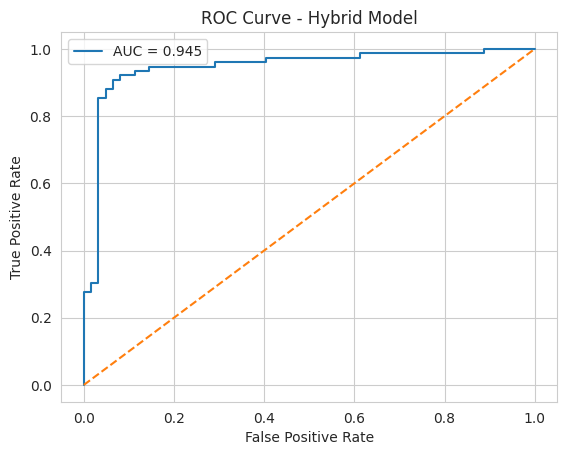

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, results_hybrid["Hybrid_Prob"])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {hybrid_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model")
plt.legend()
plt.show()

The system combines machine learning and ANFIS using a confidence-based hybrid approach. It not only predicts disease risk but also evaluates uncertainty and provides clinically meaningful decisions, ensuring reliability and trust in medical applications.

# UNCERTAINTY INTERVAL PLOT

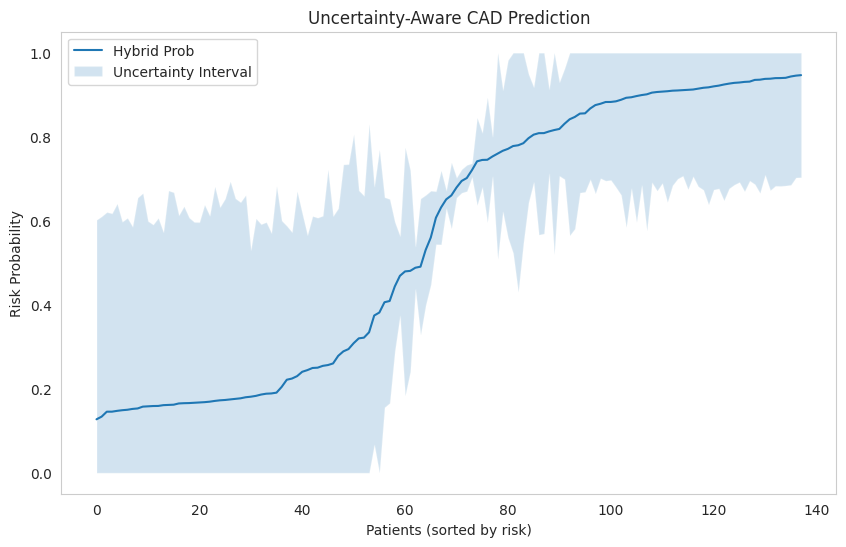

In [22]:
 
# ============================================================
# 📊 UNCERTAINTY VISUALIZATION
# ============================================================
plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(hybrid_prob)
plt.plot(hybrid_prob[sorted_idx], label="Hybrid Prob")
plt.fill_between(range(len(hybrid_prob)),
                 lower_bounds[sorted_idx], upper_bounds[sorted_idx],
                 alpha=0.2, label="Uncertainty Interval")
plt.title("Uncertainty-Aware CAD Prediction")
plt.xlabel("Patients (sorted by risk)")
plt.ylabel("Risk Probability")
plt.legend()
plt.grid()
plt.show()
 

# External Validation

In [23]:
# ============================================================
# 🌍 EXTERNAL VALIDATION — HYBRID MODEL (GBM + ANFIS)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ============================================================
# 1. LOAD & PREPROCESS EXTERNAL DATA
# ============================================================

external_df = pd.read_csv(
    "/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv"
)

# Rename target
external_df.rename(columns={"condition": "CAD"}, inplace=True)

# Column mapping (match training)
column_mapping = {
    "age": "Age", "sex": "Gender", "cp": "ChestPainType",
    "trestbps": "RestingBP", "chol": "Cholesterol", "fbs": "FastingBS",
    "restecg": "RestingECG", "thalach": "MaxHR", "exang": "ExerciseAngina",
    "oldpeak": "Oldpeak", "slope": "ST_Slope",
}
external_df.rename(columns=column_mapping, inplace=True)

# Category mapping
external_df["ChestPainType"]  = external_df["ChestPainType"].map({0:"TA",1:"ATA",2:"NAP",3:"ASY"})
external_df["Gender"]         = external_df["Gender"].map({1:"M", 0:"F"})
external_df["ExerciseAngina"] = external_df["ExerciseAngina"].map({1:"Y", 0:"N"})

# Drop unused columns
external_df = external_df.drop(columns=["ca", "thal"], errors="ignore")

# One-hot encoding
external_df = pd.get_dummies(external_df, drop_first=True)

# Split
external_X = external_df.drop("CAD", axis=1)
external_y = external_df["CAD"]

# Align columns with training data
external_X = external_X.reindex(columns=X.columns, fill_value=0)

# ============================================================
# 2. GBM PART (CALIBRATED)
# ============================================================

# Scale
external_X_scaled = scaler.transform(external_X)

# Calibrated probability (VERY IMPORTANT)
ext_prob_gbm = platt_model.predict_proba(external_X_scaled)[:, 1]

# ============================================================
# 3. ANFIS PART
# ============================================================

# Feature selection (same as training)
external_X_fs = external_X_scaled[:, [list(X.columns).index(f) for f in top_features]]

# Polynomial features
external_X_poly = poly.transform(external_X_fs)

# ANFIS ensemble prediction
raw_ext_anfis = np.array([m.forward(external_X_poly) for m in anfis_ensemble])
ext_prob_anfis = raw_ext_anfis.mean(axis=0)

# Stability clipping
ext_prob_anfis = np.clip(ext_prob_anfis, 0.05, 0.95)

# ============================================================
# 4. HYBRID FUSION (SAME LOGIC AS TRAINING)
# ============================================================

uncertainty_ext = np.abs(ext_prob_gbm - ext_prob_anfis)
confidence_ext  = np.exp(-2 * uncertainty_ext)

alpha_ext = 0.6 + 0.4 * confidence_ext

hybrid_ext_prob = (alpha_ext * ext_prob_gbm) + ((1 - alpha_ext) * ext_prob_anfis)

# Confidence bounds (optional but good)
lower_ext = np.maximum(0, hybrid_ext_prob - uncertainty_ext)
upper_ext = np.minimum(1, hybrid_ext_prob + uncertainty_ext)

# ============================================================
# 5. FINAL PREDICTION
# ============================================================

hybrid_ext_pred = (hybrid_ext_prob >= 0.5).astype(int)

# ============================================================
# 6. CLINICAL DECISION (OPTIONAL BUT STRONG)
# ============================================================

def clinical_decision_final(p, c):
    if p > 0.8:
        return ("High Risk (Uncertain)" if c < 0.4 else "High Risk")
    elif p > 0.5:
        return ("Moderate Risk (Uncertain)" if c < 0.4 else "Moderate Risk")
    else:
        return ("Low Risk (Uncertain)" if c < 0.4 else "Low Risk")

decisions_ext = [
    clinical_decision_final(p, c)
    for p, c in zip(hybrid_ext_prob, confidence_ext)
]

# ============================================================
# 7. EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("🌍 HYBRID MODEL — EXTERNAL VALIDATION")
print("=" * 60)

print(f"Accuracy : {accuracy_score(external_y, hybrid_ext_pred):.4f}")
print(f"AUC      : {roc_auc_score(external_y, hybrid_ext_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(external_y, hybrid_ext_pred))

# ============================================================
# 8. SAVE RESULTS (OPTIONAL FOR PAPER)
# ============================================================

results_external = pd.DataFrame({
    "GBM_Prob": ext_prob_gbm,
    "ANFIS_Prob": ext_prob_anfis,
    "Hybrid_Prob": hybrid_ext_prob,
    "Lower": lower_ext,
    "Upper": upper_ext,
    "Confidence": confidence_ext,
    "Decision": decisions_ext
})

print("\nSample Results:")
print(results_external.head())


🌍 HYBRID MODEL — EXTERNAL VALIDATION
Accuracy : 0.8182
AUC      : 0.9479

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.72      0.81       160
           1       0.74      0.93      0.83       137

    accuracy                           0.82       297
   macro avg       0.83      0.83      0.82       297
weighted avg       0.84      0.82      0.82       297


Sample Results:
   GBM_Prob  ANFIS_Prob  Hybrid_Prob     Lower     Upper  Confidence  \
0  0.280977    0.694543     0.374062  0.000000  0.787628    0.437302   
1  0.115824    0.549983     0.216608  0.000000  0.650767    0.419657   
2  0.103698    0.616219     0.235153  0.000000  0.747674    0.358781   
3  0.541921    0.655966     0.551225  0.437180  0.665270    0.796053   
4  0.400889    0.665235     0.444308  0.179962  0.708653    0.589376   

               Decision  
0              Low Risk  
1              Low Risk  
2  Low Risk (Uncertain)  
3         Moderate R

# Feature Distribution 

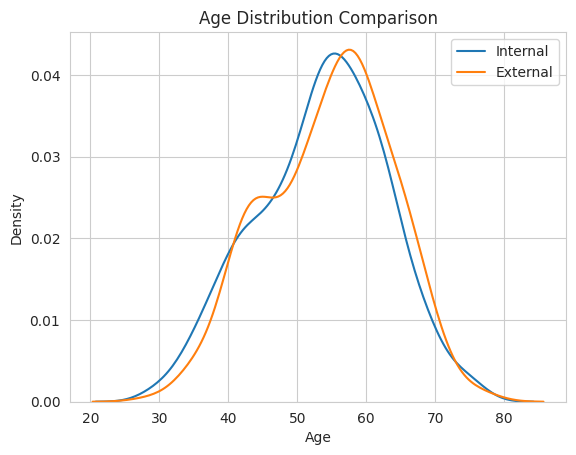

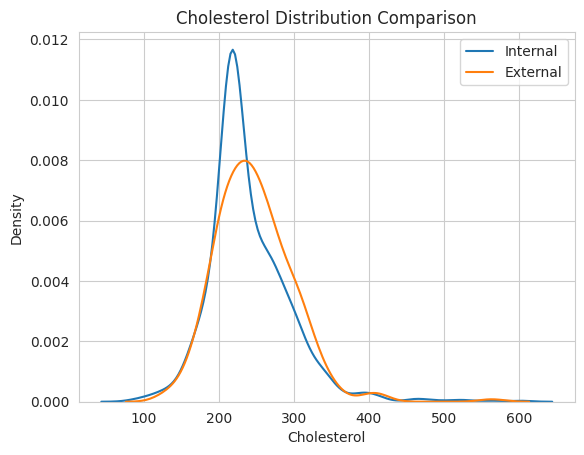

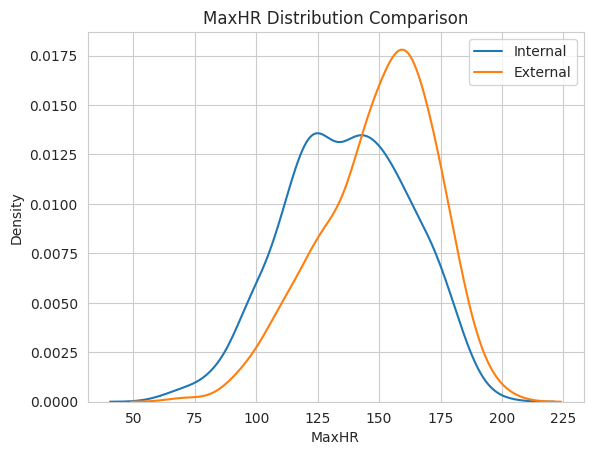

In [24]:
# ============================================================
# 📊 FEATURE DISTRIBUTION COMPARISON
# ============================================================
for col in ["Age", "Cholesterol", "MaxHR"]:
    plt.figure()
    sns.kdeplot(df[col], label="Internal")
    sns.kdeplot(external_df[col], label="External")
    plt.title(f"{col} Distribution Comparison")
    plt.legend()
    plt.show()


# Delong Test

In [25]:
# # ============================================================
# # 🔬 AUC GENERALISATION TEST — Internal vs External
# # ============================================================

from sklearn.utils import resample

def bootstrap_auc(y_true, y_prob, n=1000):
    scores = []
    for _ in range(n):
        y_s, p_s = resample(y_true, y_prob)
        scores.append(roc_auc_score(y_s, p_s))
    return np.mean(scores), np.std(scores)

gbm_mean, gbm_std = bootstrap_auc(y_test, y_prob_cal)
hyb_mean, hyb_std = bootstrap_auc(y_test, results_hybrid["Hybrid_Prob"])

print("\nBootstrap AUC Comparison:")
print(f"GBM    : {gbm_mean:.4f} ± {gbm_std:.4f}")
print(f"Hybrid : {hyb_mean:.4f} ± {hyb_std:.4f}")




Bootstrap AUC Comparison:
GBM    : 0.9473 ± 0.0210
Hybrid : 0.9449 ± 0.0221


# Clinical Decision Threshold

In [26]:
# ============================================================
# 🏥 CLINICAL DECISION THRESHOLD LAYER
# ============================================================
def clinical_decision(prob):
    if prob >= 0.7:
        return "🔴 High Risk → Refer to Cardiologist"
    elif prob >= 0.3:
        return "🟡 Moderate Risk → Further Tests"
    else:
        return "🟢 Low Risk → Routine Monitoring"
 
 
sample_results = pd.DataFrame({
    "Predicted Probability (%)": (y_prob_cal[:15] * 100).round(2),
    "Clinical Decision"         : [clinical_decision(p) for p in y_prob_cal[:15]]
})
print("\n🏥 Clinical Decision Support Output (Sample):")
print(sample_results)
 


🏥 Clinical Decision Support Output (Sample):
    Predicted Probability (%)                    Clinical Decision
0                        3.09      🟢 Low Risk → Routine Monitoring
1                        5.49      🟢 Low Risk → Routine Monitoring
2                       76.04  🔴 High Risk → Refer to Cardiologist
3                       36.65      🟡 Moderate Risk → Further Tests
4                       98.14  🔴 High Risk → Refer to Cardiologist
5                       74.92  🔴 High Risk → Refer to Cardiologist
6                        2.76      🟢 Low Risk → Routine Monitoring
7                        4.05      🟢 Low Risk → Routine Monitoring
8                        6.83      🟢 Low Risk → Routine Monitoring
9                       84.55  🔴 High Risk → Refer to Cardiologist
10                      10.70      🟢 Low Risk → Routine Monitoring
11                      12.68      🟢 Low Risk → Routine Monitoring
12                       1.07      🟢 Low Risk → Routine Monitoring
13              

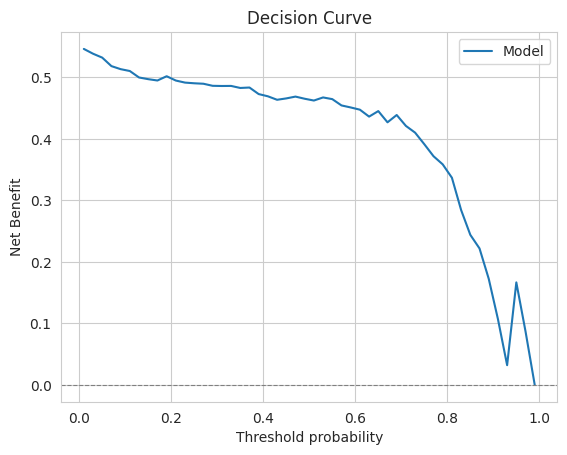

In [27]:
# ============================================================
# 📉 DECISION CURVE
# ============================================================
thresholds   = np.linspace(0.01, 0.99, 50)
net_benefit  = []
for t in thresholds:
    preds = (y_prob_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    nb = (tp / len(y_test)) - (fp / len(y_test)) * (t / (1 - t))
    net_benefit.append(nb)
 
plt.figure()
plt.plot(thresholds, net_benefit, label="Model")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Threshold probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve")
plt.legend()
plt.show()
 

# Decision Curve

In [28]:
# ============================================================
# 🛡️ MODEL STABILITY — 5-Fold CV on Best Model
# ============================================================
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_auc      = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
 
print("🛡️ Model Stability Analysis (5-Fold CV on scaled train set):")
print(f"  Mean CV Accuracy : {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std()*2:.4f})")
print(f"  Mean CV AUC      : {cv_auc.mean():.4f} (+/- {cv_auc.std()*2:.4f})")

🛡️ Model Stability Analysis (5-Fold CV on scaled train set):
  Mean CV Accuracy : 0.8704 (+/- 0.0645)
  Mean CV AUC      : 0.9358 (+/- 0.0388)


# Save assets

In [29]:
# ============================================================
# 💾 SAVE ASSETS
# ============================================================
joblib.dump(model,               "cad_model.pkl")
joblib.dump(platt_model,         "cad_model_calibrated.pkl")
joblib.dump(scaler,              "scaler.pkl")
joblib.dump(X.columns.tolist(),  "features.pkl")
 
print("\n✅ FINAL SYSTEM COMPLETE")


✅ FINAL SYSTEM COMPLETE
